# EDA — How many items has each customer purchased?

Uses **line-level** sales from `data/raw_data.csv` (or MySQL `load_interactions` if the CSV is missing), same grain as `data_prep`.

Two useful counts per customer:

1. **Line items** — number of **sales lines** (same product on different orders counts multiple times)
2. **Distinct products** — number of **unique `ProductID`** that customer has ever bought

The **maximum** you care about depends on the question: “most lines” vs “most unique products.”

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_assignment2_root() -> Path:
    p = Path.cwd().resolve()
    for cand in [p, *p.parents]:
        if (cand / "src" / "data_prep.py").exists():
            return cand
    raise FileNotFoundError(
        "Could not find assignment2 root. Run the notebook from assignment2/ or notebooks/."
    )


ROOT = find_assignment2_root()
sys.path.insert(0, str(ROOT / "src"))

from data_prep import load_interactions  # noqa: E402

try:
    from IPython.display import display
except ImportError:
    display = print

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["figure.dpi"] = 100

print("Repo root:", ROOT)

Repo root: /root/assignment2


In [2]:
RAW_CSV = ROOT / "data" / "raw_data.csv"

if RAW_CSV.exists():
    df = pd.read_csv(RAW_CSV, parse_dates=["OrderDate"])
    print(f"Loaded {len(df):,} sales lines from {RAW_CSV.name}")
else:
    df = load_interactions()
    print(f"Loaded {len(df):,} sales lines from MySQL")

df = df.dropna(subset=["CustomerID", "ProductID"])
df["CustomerID"] = df["CustomerID"].astype(np.int64)
df["ProductID"] = df["ProductID"].astype(np.int64)

n_customers = df["CustomerID"].nunique()
print(f"Distinct customers: {n_customers:,}")

Loaded 60,398 sales lines from raw_data.csv
Distinct customers: 18,484


In [3]:
g = df.groupby("CustomerID", sort=False).agg(
    n_line_items=("ProductID", "size"),
    n_distinct_products=("ProductID", "nunique"),
)

summary = pd.DataFrame(
    {
        "metric": [
            "max line items (any one customer)",
            "max distinct products (any one customer)",
        ],
        "value": [int(g["n_line_items"].max()), int(g["n_distinct_products"].max())],
    }
)
display(summary)

idx_lines = g["n_line_items"].idxmax()
idx_distinct = g["n_distinct_products"].idxmax()
print(f"Customer with most sales lines: {int(idx_lines)}  ({g.loc[idx_lines, 'n_line_items']:.0f} lines)")
print(
    f"Customer with most distinct products: {int(idx_distinct)}  "
    f"({g.loc[idx_distinct, 'n_distinct_products']:.0f} unique products)"
)

,metric,value
0,max line items (any one customer),68
1,max distinct products (any one customer),29


Customer with most sales lines: 11185  (68 lines)
Customer with most distinct products: 11185  (29 unique products)


In [4]:
desc = g.describe(percentiles=[0.5, 0.9, 0.99]).T
# pandas uses "50%" for median in describe
display(desc.round(2))

,count,mean,std,min,50%,90%,99%,max
n_line_items,18484.0,3.27,2.62,1.0,3.0,5.0,10.0,68.0
n_distinct_products,18484.0,3.19,1.95,1.0,3.0,5.0,10.0,29.0


In [5]:
# Top 10 customers by sales-line count and by distinct products
top_lines = g.sort_values("n_line_items", ascending=False).head(10).reset_index()
top_distinct = g.sort_values("n_distinct_products", ascending=False).head(10).reset_index()
display(top_lines)
display(top_distinct)

,CustomerID,n_line_items,n_distinct_products
0,11185,68,29
1,11300,67,28
2,11277,65,26
3,11262,63,26
4,11287,62,23
5,11176,60,27
6,11091,59,25
7,11566,58,15
8,11331,58,24
9,11276,57,22


,CustomerID,n_line_items,n_distinct_products
0,11185,68,29
1,11300,67,28
2,11176,60,27
3,11711,55,27
4,11262,63,26
5,11223,56,26
6,11277,65,26
7,11200,55,26
8,11091,59,25
9,11502,43,25


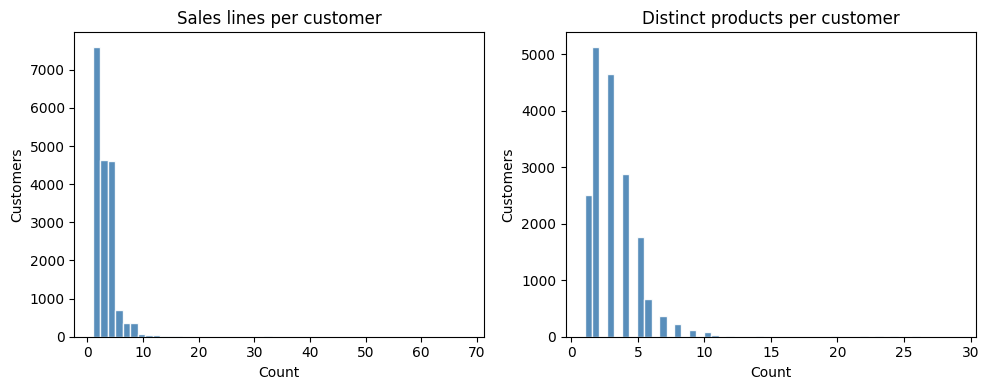

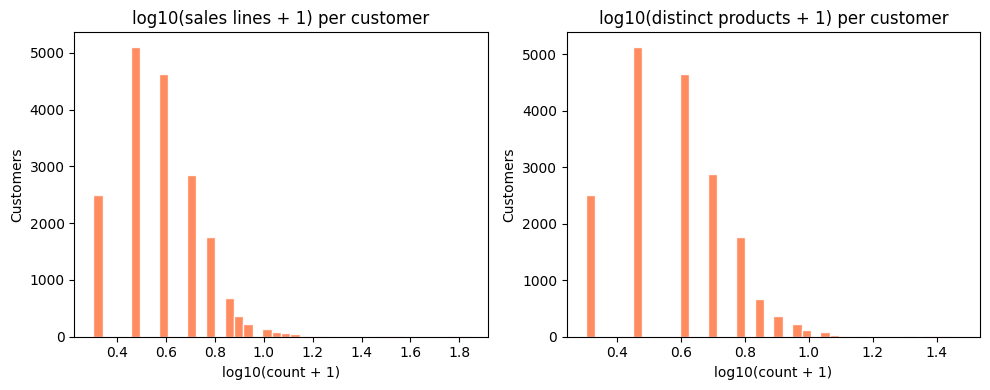

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, title in zip(
    axes,
    ["n_line_items", "n_distinct_products"],
    ["Sales lines per customer", "Distinct products per customer"],
):
    x = g[col]
    # Log scale is easier when there is a long right tail
    ax.hist(x, bins=50, color="steelblue", edgecolor="white", alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel("Count")
    ax.set_ylabel("Customers")
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, title in zip(
    axes2,
    ["n_line_items", "n_distinct_products"],
    ["log10(sales lines + 1) per customer", "log10(distinct products + 1) per customer"],
):
    v = np.log10(g[col].values + 1)
    ax.hist(v, bins=40, color="coral", edgecolor="white", alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel("log10(count + 1)")
    ax.set_ylabel("Customers")
plt.tight_layout()
plt.show()

In [7]:
n_unique_products = df["ProductID"].nunique()
print(f"Unique products in the dataset: {n_unique_products:,}")

Unique products in the dataset: 130
